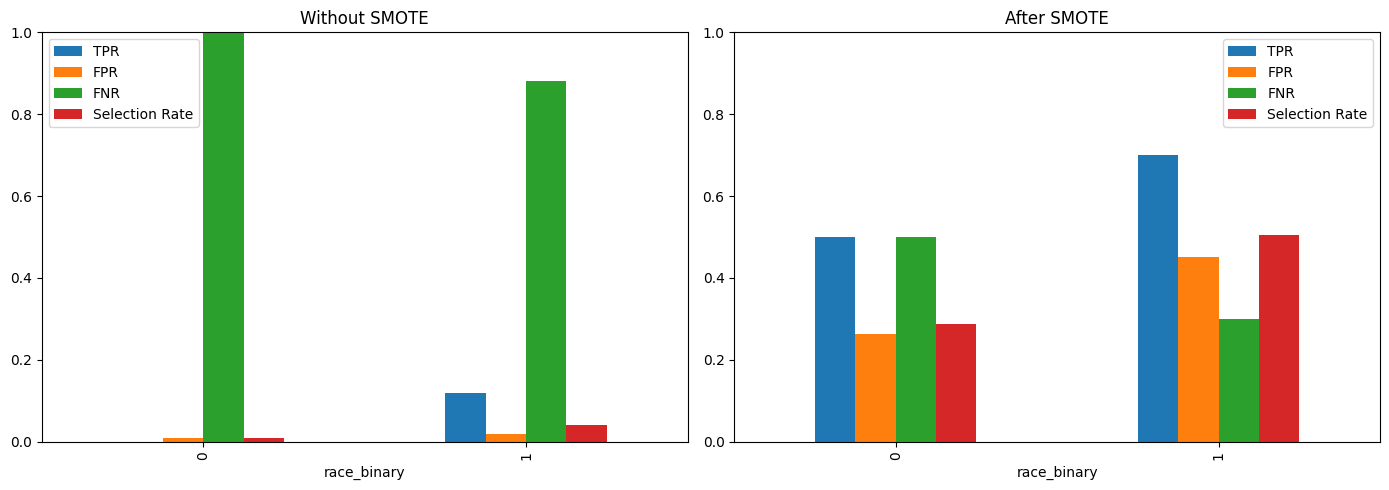

📊 Fairness Metrics WITHOUT SMOTE:
              Accuracy   TPR       FPR   FNR  Selection Rate
race_binary                                                
0            0.886275  0.00  0.008772  1.00        0.007843
1            0.791483  0.12  0.018832  0.88        0.041116

📊 Fairness Metrics WITH SMOTE:
              Accuracy  TPR       FPR  FNR  Selection Rate
race_binary                                              
0            0.711765  0.5  0.263158  0.5        0.288235
1            0.582966  0.7  0.450094  0.3        0.505140


In [26]:
# ✅ STEP 1: Install required libraries (run only once in your environment)
# !pip install pandas seaborn matplotlib scikit-learn imbalanced-learn fairlearn

# ✅ STEP 2: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

from imblearn.over_sampling import SMOTE
from fairlearn.metrics import MetricFrame, selection_rate, true_positive_rate, false_positive_rate, false_negative_rate

# ✅ STEP 3: Load dataset
df = pd.read_csv("compas-scores-two-years-violent.csv")

# Filter to only two races for fairness
df = df[df['race'].isin(['African-American', 'Caucasian'])]
df = df.dropna(subset=['age', 'priors_count', 'c_charge_degree', 'two_year_recid'])

# Encode categorical and target variables
df = pd.get_dummies(df, columns=['c_charge_degree'], drop_first=True)
df['race_binary'] = df['race'].map({'Caucasian': 0, 'African-American': 1})
y = df['two_year_recid'].astype(int)
X = df[['age', 'priors_count'] + [col for col in df.columns if 'c_charge_degree' in col]]
sensitive_features = df['race_binary']

# ✅ STEP 4: Split data
X_train, X_test, y_train, y_test, s_train, s_test = train_test_split(
    X, y, sensitive_features, test_size=0.3, random_state=42, stratify=y
)

# ✅ STEP 5: Train baseline model (without SMOTE)
model_orig = LogisticRegression(max_iter=1000)
model_orig.fit(X_train, y_train)
y_pred_orig = model_orig.predict(X_test)

mf_orig = MetricFrame(
    metrics={
        'Accuracy': accuracy_score,
        'TPR': true_positive_rate,
        'FPR': false_positive_rate,
        'FNR': false_negative_rate,
        'Selection Rate': selection_rate
    },
    y_true=y_test,
    y_pred=y_pred_orig,
    sensitive_features=s_test
)

# ✅ STEP 6: Apply SMOTE to balance dataset
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

model_sm = LogisticRegression(max_iter=1000)
model_sm.fit(X_train_sm, y_train_sm)
y_pred_sm = model_sm.predict(X_test)

mf_sm = MetricFrame(
    metrics={
        'Accuracy': accuracy_score,
        'TPR': true_positive_rate,
        'FPR': false_positive_rate,
        'FNR': false_negative_rate,
        'Selection Rate': selection_rate
    },
    y_true=y_test,
    y_pred=y_pred_sm,
    sensitive_features=s_test
)

# ✅ STEP 7: Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
mf_orig.by_group[['TPR', 'FPR', 'FNR', 'Selection Rate']].plot.bar(ax=axes[0])
axes[0].set_title("Without SMOTE")
axes[0].set_ylim(0, 1)

mf_sm.by_group[['TPR', 'FPR', 'FNR', 'Selection Rate']].plot.bar(ax=axes[1])
axes[1].set_title("After SMOTE")
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

# ✅ STEP 8: Print results
print("📊 Fairness Metrics WITHOUT SMOTE:\n", mf_orig.by_group)
print("\n📊 Fairness Metrics WITH SMOTE:\n", mf_sm.by_group)
